# Activity scoring of senescence marker genes 
#### To generate a score for each cell/sample, the z-scored expression values were filtered for the genes of interest, converted to indicate concordance or discordance with the direction of change in the gene set (includes directionality metadata), and averaged. A positive resulting score indicates a similar expression pattern to the gene-set signature compared to the other cells/samples in the data set

In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import GSVA
import matplotlib.pyplot as plt
import numpy as np


In [2]:
def calculate_senescence_score(data, up_genes=None, down_genes=None, method='zscore'):
    """
    Calculate senescence signature scores for each sample based on DEGs from gene-sets
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame with genes as rows and samples as columns (first column should be 'NAME' or gene names)
    up_genes : list, optional
        Genes upregulated in senescent cells (default: None)
    down_genes : list, optional
        Genes downregulated in senescent cells (default: None)
    method : str, optional  
        Scoring method ('zscore' or 'gsva'). Default is 'zscore'
        
    Returns:
    --------
    scores_df : pd.DataFrame
        DataFrame with sample names as index and 'senescence_score' as column
    """
    if up_genes is None and down_genes is None:
        raise ValueError("At least one of up_genes or down_genes must be provided")
    
    # Set index to gene names if not alrea    dy done
    if 'NAME' in data.columns:
        data = data.set_index('NAME')
    if 'Description' in data.columns:
        data = data.drop('Description', axis=1)
    
    # Check which genes are present in the expression data
    available_genes = set(data.index)
    
    # Process up-regulated genes
    if up_genes is not None:
        up_genes_set = set(up_genes)
        up_genes = list(up_genes_set.intersection(available_genes))
        print(f"Using {len(up_genes)} upregulated genes")
    
    # Process down-regulated genes
    if down_genes is not None:
        down_genes_set = set(down_genes)
        down_genes = list(down_genes_set.intersection(available_genes))
        print(f"Using {len(down_genes)} downregulated genes")
    
    # Check if we have enough genes to proceed
    if (up_genes is None or len(up_genes) == 0) and (down_genes is None or len(down_genes) == 0):
        raise ValueError("No genes from the gene sets were found in the expression data")
    
    sample_names = data.columns
    expr_matrix = data.select_dtypes(include=[np.number])
    
    # Z-standardize the expression values across samples
    z_standardized = (expr_matrix - expr_matrix.mean(axis=1).values.reshape(-1, 1)) / \
                    expr_matrix.std(axis=1).values.reshape(-1, 1)
    
    # Calculate scores for each sample
    scores = pd.Series(0, index=sample_names)
    
    # Calculate total gene set size for normalization
    total_genes = 0
    if up_genes:
        total_genes += len(up_genes)
    if down_genes:
        total_genes += len(down_genes)
    
    # Calculate combined score with size normalization
    if up_genes:
        up_score = z_standardized.loc[up_genes].sum()
        scores += up_score
    
    if down_genes:
        down_score = z_standardized.loc[down_genes].sum()
        scores -= down_score  # Subtract because these are down-regulated
    
    # Normalize by square root of gene set size
    scores = scores / np.sqrt(total_genes)
    
    # Final z-score normalization across samples
    scores = (scores - scores.mean()) / scores.std()
    
    # Convert to DataFrame with meaningful column name
    scores_df = pd.DataFrame(scores, columns=['senescence_score'])
    
    return scores_df

In [ ]:
# GSVA score calculation

In [3]:
def map_sample_to_category(sample_name):
    """Map sample names to their experimental categories"""
    if sample_name in ['AV01', 'AV02', 'AV03', 'AV04', 'AV05']:
        return 'Ctrl Low-Fat diet'
    elif sample_name in ['AV06', 'AV07', 'AV08', 'AV09', 'AV10']:
        return 'Trf2 KO Low-Fat diet'
    elif sample_name in ['AV11', 'AV12', 'AV13', 'AV14', 'AV15']:
        return 'Ctrl Western diet'
    elif sample_name in ['AV16', 'AV17', 'AV18', 'AV19', 'AV20']:
        return 'Trf2 KO Western diet'
    return None

In [4]:
data_dir = '/ocean/projects/cis240075p/asachan/datasets/senescence_datasets/mouse_liver/'
sensig_geneset = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/SenSig_DEGs.csv'
fridman_down_orthologs = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/fridman_down_orthologs.csv'
fridman_up_orthologs = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/fridman_up_orthologs.csv'
senmayo_geneset = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/SAUL_SEN_MAYO_UP_IN_SEN.v2024.1.Mm.gmt'
cell_age_orthologs = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/cellAge_orthologs.csv'
cell_age_human = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/cellAge/cellage3.tsv'

In [5]:
counts = pd.read_csv(os.path.join(data_dir, 'Trf2_Liver_NormCounts_GSEA.gct.txt'), sep='\t', skiprows=2)
expr_df = counts.set_index('NAME')
expr_df = expr_df.drop('Description', axis=1)
expr_df = expr_df.select_dtypes(include=[np.number])
expr_df = expr_df.dropna()  # Remove rows with NaN values
display(expr_df.head())

,AV01,AV02,AV03,AV04,AV05,AV06,AV07,AV08,AV09,AV10,AV11,AV12,AV13,AV14,AV15,AV16,AV17,AV18,AV19,AV20
NAME,,,,,,,,,,,,,,,,,,,,
Xkr4,4.202855,0.000000,0.000000,0.000000,5.489411,0.701450,3.115962,0.000000,0.000000,1.242640,0.000000,0.000000,0.000000,0.000000,0.000000,1.030429,1.642052,0.000000,0.000000,0.781083
Sox17,104.020668,68.775083,40.865415,66.229103,112.532935,65.234839,41.753890,22.378785,36.146543,57.161443,35.110845,77.113697,34.697691,77.299154,32.474227,69.038745,38.588215,25.167334,75.172195,53.894700
Mrpl15,799.593217,741.977338,1061.298871,837.755151,796.879567,824.203605,1042.600871,1112.053462,1459.572458,884.759722,918.935553,823.714489,965.752406,784.883722,875.756567,771.791345,1004.935644,1039.201182,818.875780,712.347336
Lypla1,3446.341331,3227.138511,1094.952743,1937.846361,2074.082640,3115.840354,2166.839945,587.873463,575.851815,1656.439199,2242.251179,3189.702914,739.253588,2547.304444,2159.012302,3899.143454,1620.705034,557.875912,2234.117643,2814.240627
LOC118567656,3.152141,5.290391,0.000000,0.000000,0.000000,2.104350,1.246385,2.582167,0.000000,1.242640,3.632156,4.673557,0.000000,0.000000,2.095111,3.091287,0.821026,0.000000,4.009184,2.343248


#### SenSig

In [6]:
#SenSig
sensig_genes = pd.read_csv(sensig_geneset, skiprows=1)
print(sensig_genes.head())
sensig_up_genes = sensig_genes[sensig_genes['logFC'] > 0]['Gene'].tolist()  
sensig_down_genes = sensig_genes[sensig_genes['logFC'] < 0]['Gene'].tolist()
print(len(sensig_up_genes))
print(len(sensig_down_genes))


      Gene     logFC    logCPM           F        PValue           FDR
0  Aldh1a3 -1.537131  5.312493  317.399525  2.000000e-11  2.250000e-07
1   Card10 -1.329801  6.905892  308.235873  2.460000e-11  2.250000e-07
2   Errfi1 -1.277384  9.671747  285.153969  4.270000e-11  2.610000e-07
3      Tek -1.774617  8.228041  240.112909  1.430000e-10  6.560000e-07
4     Car8 -2.359974  5.802668  203.895757  4.490000e-10  1.640000e-06
8567
9069


#### Fridman

In [22]:
#Fridman gene sets
fridman_down_orthologs = pd.read_csv(fridman_down_orthologs, sep=',', header=0)['ortholog_name'].tolist()
fridman_up_orthologs = pd.read_csv(fridman_up_orthologs, sep=',', header=0)['ortholog_name'].tolist()
display(fridman_down_orthologs[0:5])
display(fridman_up_orthologs[0:5])


['Aldh1a7', 'Aldh1a1', 'Bmi1', 'Ccn4', 'Ccnb1']

['Aldh1a3', 'Aopep', 'Ccn2', 'Ccnd1', 'Cd44']

#### SenMayo

In [8]:
#SenMayo
senmayo_genes = pd.read_csv(senmayo_geneset, sep='\t', header=None)
senmayo_up_genes = senmayo_genes.iloc[0, 2:].dropna().tolist()
display(senmayo_up_genes[0:5])


['Acvr1b', 'Ang', 'Angpt1', 'Angptl4', 'Areg']

#### CellAge

In [11]:
cellage_orthologs = pd.read_csv(cell_age_orthologs, sep=',', header=0)
cellage_human = pd.read_csv(cell_age_human, sep='\t', header=0)
# Merge based on initial_alias (from orthologs) matching Gene symbol (from cellage)
merged = pd.merge(
    cellage_orthologs[['ortholog_name', 'initial_alias']], # Keep only these columns
    cellage_human[['Gene symbol', 'Senescence Effect']],
    left_on='initial_alias',
    right_on='Gene symbol',
    how='left'
)

# Clean up the merged dataframe
merged = merged.drop('Gene symbol', axis=1)  # Remove the redundant column
cellage_ortholog_genes = merged.rename(columns={'initial_alias': 'human_gene'})
# get the cellage_up_genes as ortholog_name
cellage_up_genes = cellage_ortholog_genes[cellage_ortholog_genes['Senescence Effect'] == 'Induces']['ortholog_name'].tolist()
display(cellage_up_genes[0:5])
# get the cellage_down_genes as ortholog_name 
cellage_down_genes = cellage_ortholog_genes[cellage_ortholog_genes['Senescence Effect'] == 'Inhibits']['ortholog_name'].tolist()
display(cellage_down_genes[0:5])


['Aak1', 'Abcb1b', 'Abcb1a', 'Abi3', 'Abi3bp']

['Abcc6', 'Acer2', 'Acer2', 'Acer2', 'Acer2']

## Get the senescence scores

In [14]:
#SenSig
sensig_scores = calculate_senescence_score(expr_df, up_genes=sensig_up_genes, down_genes=sensig_down_genes)
sensig_up_scores = calculate_senescence_score(expr_df, up_genes=sensig_up_genes)
sensig_down_scores = calculate_senescence_score(expr_df, down_genes=sensig_down_genes)
# add category to the sample names
sensig_scores['category'] = sensig_scores.index.map(map_sample_to_category)
sensig_up_scores['category'] = sensig_up_scores.index.map(map_sample_to_category)
sensig_down_scores['category'] = sensig_down_scores.index.map(map_sample_to_category)


Using 7088 upregulated genes
Using 7353 downregulated genes
Using 7088 upregulated genes
Using 7353 downregulated genes


In [23]:
#Fridman
fridman_scores = calculate_senescence_score(expr_df, up_genes=fridman_up_orthologs, down_genes=fridman_down_orthologs)
fridman_up_scores = calculate_senescence_score(expr_df, up_genes=fridman_up_orthologs)
fridman_down_scores = calculate_senescence_score(expr_df, down_genes=fridman_down_orthologs)
fridman_up_scores['category'] = fridman_up_scores.index.map(map_sample_to_category)
fridman_down_scores['category'] = fridman_down_scores.index.map(map_sample_to_category)
fridman_scores['category'] = fridman_scores.index.map(map_sample_to_category)

Using 82 upregulated genes
Using 13 downregulated genes
Using 82 upregulated genes
Using 13 downregulated genes


In [21]:
#SenMayo
senmayo_scores = calculate_senescence_score(expr_df, up_genes=senmayo_up_genes)
senmayo_scores['category'] = senmayo_scores.index.map(map_sample_to_category)


Using 106 upregulated genes


In [12]:
#CellAge
cellage_scores = calculate_senescence_score(expr_df, up_genes=cellage_up_genes, down_genes=cellage_down_genes)
cellage_up_scores = calculate_senescence_score(expr_df, up_genes=cellage_up_genes)
cellage_down_scores = calculate_senescence_score(expr_df, down_genes=cellage_down_genes)
cellage_scores['category'] = cellage_scores.index.map(map_sample_to_category)
cellage_up_scores['category'] = cellage_up_scores.index.map(map_sample_to_category)
cellage_down_scores['category'] = cellage_down_scores.index.map(map_sample_to_category)


Using 353 upregulated genes
Using 454 downregulated genes
Using 353 upregulated genes
Using 454 downregulated genes


## Plotting

In [13]:
def plot_scores_scatter(scores_df, category_colors, title=None, ylabel=None):
    """
    Create a scatter plot of senescence scores with colored labels by category
    
    Parameters:
    -----------
    scores_df : pandas DataFrame
        DataFrame containing scores and categories
    category_colors : dict
        Dictionary mapping categories to colors
    title : str, optional
        Custom title for the plot (e.g., "Fridman Senescence Signature Scores")
    ylabel : str, optional
        Custom y-axis label (e.g., "Fridman Score")
    """
    plt.figure(figsize=(12, 6))
    
    # Sort by score for clustering effect
    scores_sorted = scores_df.sort_values('senescence_score')
    
    # Create scatter plot
    plt.scatter(range(len(scores_sorted)), 
               scores_sorted['senescence_score'],
               alpha=0)  # Make points invisible
    
    # Add colored labels
    for i, (idx, row) in enumerate(scores_sorted.iterrows()):
        plt.annotate(idx,  # sample name
                    (i, row['senescence_score']),
                    color=category_colors[row['category']],
                    xytext=(0, 5),
                    textcoords='offset points',
                    ha='center',
                    fontsize=10)
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                color=color, 
                                label=cat, 
                                marker='o')
                      for cat, color in category_colors.items()]
    plt.legend(handles=legend_elements, 
              loc='center left', 
              bbox_to_anchor=(1, 0.5))
    
    # Customize plot
    plt.grid(True, alpha=0.3)
    plt.xlabel('Samples (ordered by score)')
    plt.ylabel(ylabel if ylabel else 'Senescence Score')
    plt.title(title if title else 'Senescence Scores Distribution')
    plt.xticks([])
    
    plt.tight_layout()
    plt.show()


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

def permutation_test(group1, group2, n_permutations=10000):
    """
    Perform a permutation test to compute p-value for the difference between two groups.
    
    Parameters:
    -----------
    group1, group2 : array-like
        The scores for the two groups being compared.
    n_permutations : int, optional
        Number of permutations to generate the null distribution.
    
    Returns:
    --------
    observed_diff : float
        The observed mean difference between the groups.
    p_value : float
        The p-value based on the permutation test.
    """
    observed_diff = np.mean(group1) - np.mean(group2)
    combined = np.concatenate([group1, group2])
    null_diffs = []
    
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        perm_group1 = combined[:len(group1)]
        perm_group2 = combined[len(group1):]
        null_diffs.append(np.mean(perm_group1) - np.mean(perm_group2))
    
    null_diffs = np.array(null_diffs)
    p_value = np.mean(np.abs(null_diffs) >= np.abs(observed_diff))
    return observed_diff, p_value, null_diffs

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind

def plot_scores_with_significance(scores_df, category_colors, title=None, ylabel=None, n_permutations=1000):
    plt.figure(figsize=(12, 8))

    # Create box plot
    ax = sns.boxplot(x='category', y='senescence_score', data=scores_df, palette=category_colors, width=0.5)
    sns.swarmplot(x='category', y='senescence_score', data=scores_df, color='0.2', alpha=0.6)

    # Pairwise comparisons for significance
    categories = scores_df['category'].unique()
    pairs = [
        ('Ctrl Low-Fat diet', 'Trf2 KO Low-Fat diet'),
        ('Ctrl Western diet', 'Trf2 KO Western diet'),
        ('Ctrl Low-Fat diet', 'Ctrl Western diet'),
        ('Trf2 KO Low-Fat diet', 'Trf2 KO Western diet')
    ]

    y_max = scores_df['senescence_score'].max()
    y_min = scores_df['senescence_score'].min()
    y_range = y_max - y_min

    for i, (cat1, cat2) in enumerate(pairs):
        if cat1 in categories and cat2 in categories:
            group1 = scores_df[scores_df['category'] == cat1]['senescence_score']
            group2 = scores_df[scores_df['category'] == cat2]['senescence_score']

            # Perform t-test
            _, p_value = ttest_ind(group1, group2)

            # Calculate y position
            x1 = list(categories).index(cat1)
            x2 = list(categories).index(cat2)
            y = y_max + (i + 1) * (y_range * 0.1)

            # Add significance annotation
            plt.plot([x1, x1, x2, x2], [y, y + y_range * 0.02, y + y_range * 0.02, y], color='black', lw=1)
            sig = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'ns'))
            plt.text((x1 + x2) / 2, y + y_range * 0.02, f'{sig}\np={p_value:.3f}', ha='center', va='bottom')

    # Customize plot
    plt.title(title if title else 'Scores by Category')
    plt.ylabel(ylabel if ylabel else 'Score')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(y_min - y_range * 0.3, y_max + y_range * 0.5)

    plt.tight_layout()
    plt.show()


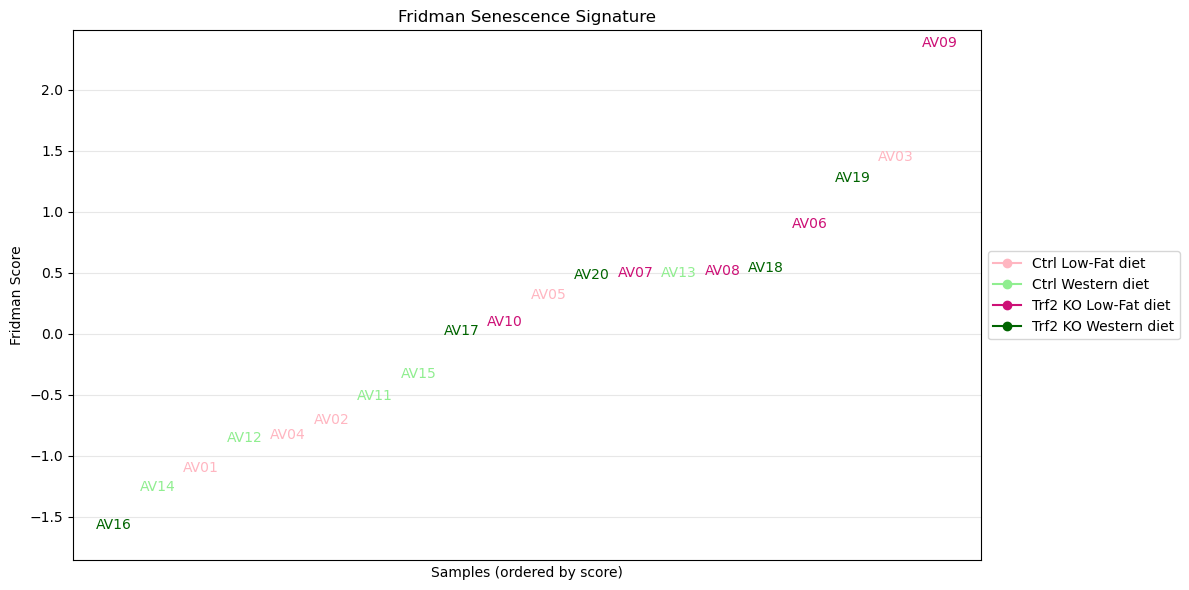

In [24]:
custom_colors = {
    'Ctrl Low-Fat diet': '#FFB6C1',      # Light pink/salmon
    'Ctrl Western diet': '#90EE90',       # Light green
    'Trf2 KO Low-Fat diet': '#CD1076',   # Deep pink
    'Trf2 KO Western diet': '#006400'     # Dark green
}

#Fridman
plot_scores_scatter(fridman_scores, 
                   category_colors=custom_colors,
                   title="Fridman Senescence Signature",
                   ylabel="Fridman Score")


/tmp/ipykernel_60026/3627782528.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='category', y='senescence_score', data=scores_df, palette=category_colors, width=0.5)


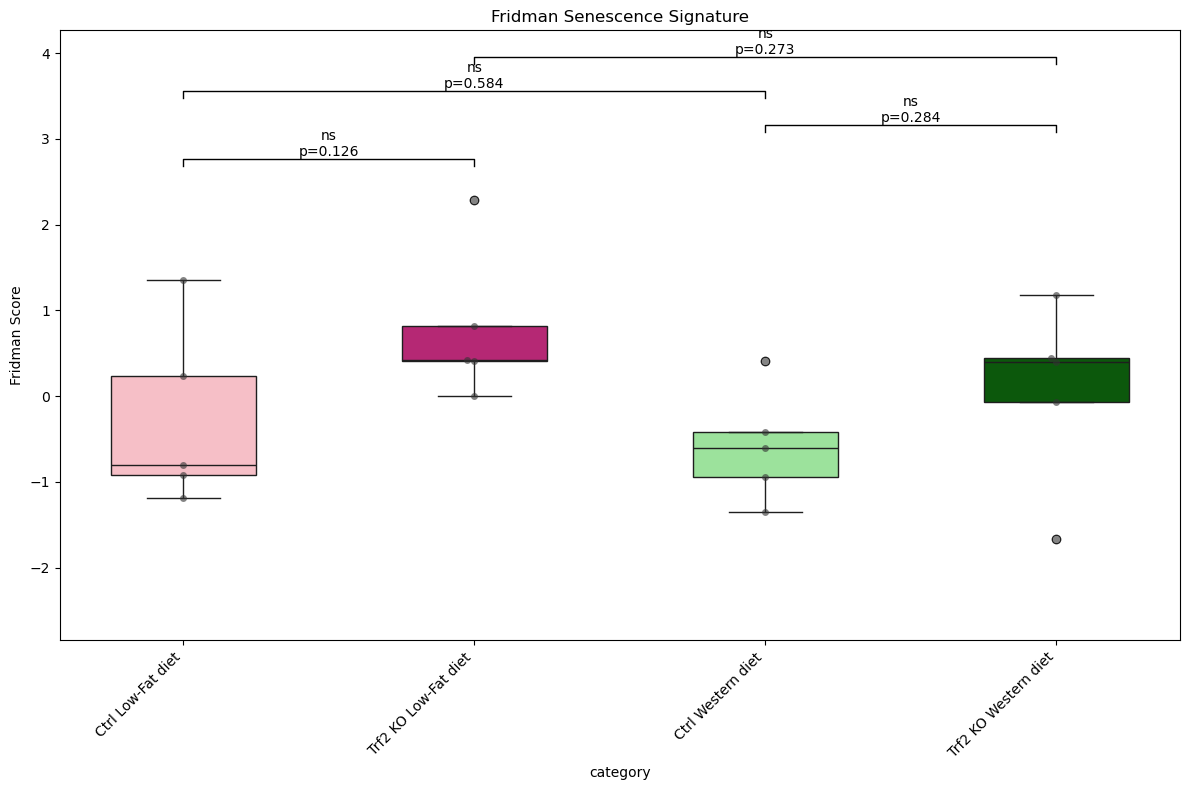

In [27]:
plot_scores_with_significance(
    scores_df=fridman_scores,
    category_colors=custom_colors,
    title="Fridman Senescence Signature",
    ylabel="Fridman Score",
    n_permutations=10000
)
